# <span style="color:red"> **LSN - Esercitazione 08**
### <span style="color:green"> 08.05.2025
#### <span style="color:green"> Lucrezia Bioni (13655A)

Note:
#### Esercizio 08.1:
- ottengo accettanza quasi sempre pari a 1, e valori di energia spesso lontani da quello atteso. Probabilmemte perché i valori di $\sigma$ e  $\mu$ non sono quelli ottimali.
#### Esercizio 08.2:
- quanti passi fare per ciascun valore di beta, cioè che n? a tentativi.
- quanti passi fare nel metropolis dell'energia? a tentativi.
- va bene il delta scelto nel metropolis dei parametri? (in funzione della temperatura) a tentativi.
- dobbiamo verificare accettanza del metropolis dei parametri? necessario cambiare continuamente delta del metropolis dell'energia per tenere accettanza al 50%? va bene come ho fatto
- è meglio calcolare H una sola volta e passarlo come argomento di metro_par oppure ricalcolarlo all'interno della funzione ogni volta? capire perché H va ricalcolata comunque (anche se rigetto mu_new e sigma_new)
- come gestire il fatto che, per sigma piccole, valuta H in punti non significativi e otteniamo valori minori del minimo? ha senso scartare i primi tot dati? se scarto qualche blocco, non ottengo schifezze iniziali, ma poi il risultato di H finale è peggio.

### <span style="color:blue">**_Simulated Annealing_**

## <span style="color:blue">**Esercizio 08.1**

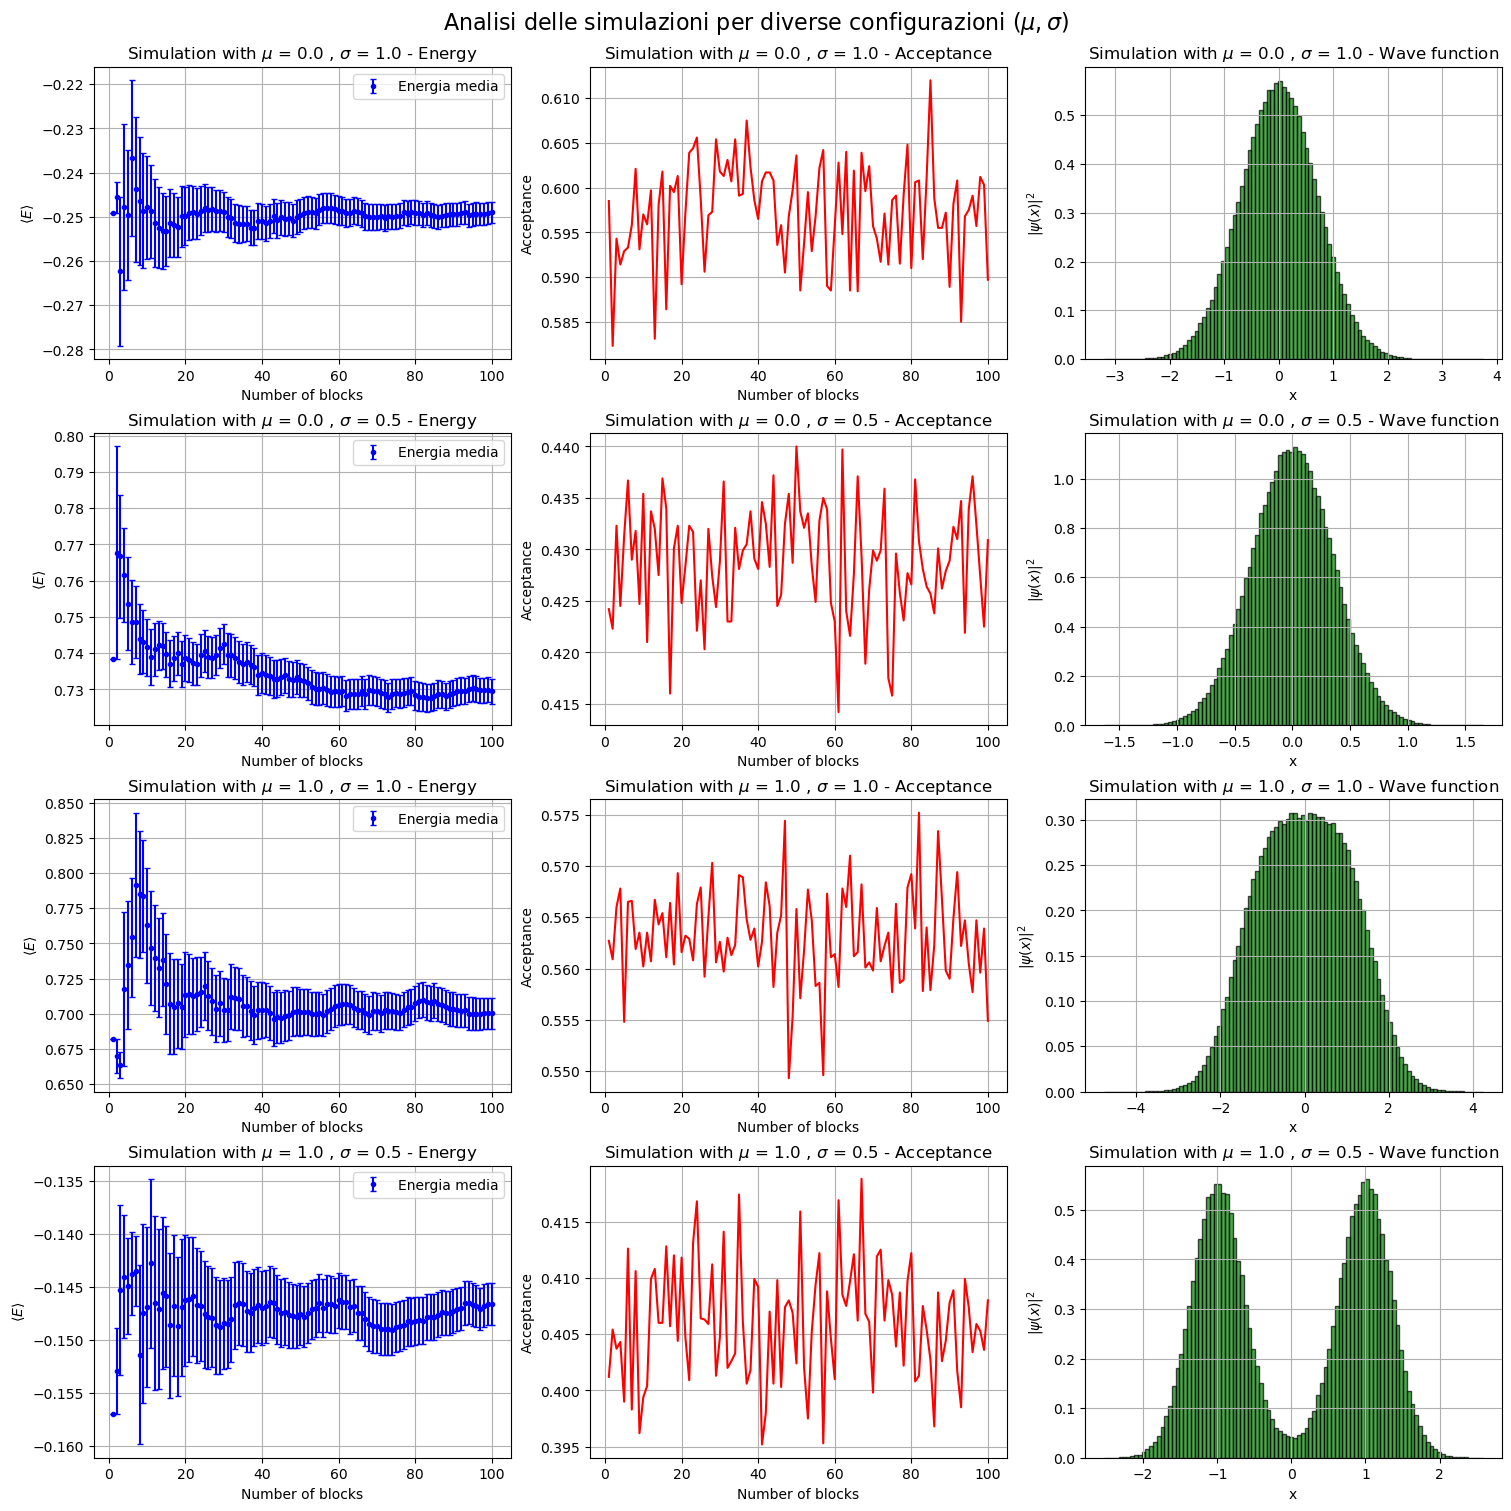

In [21]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(4, 3, figsize=(15, 15), constrained_layout=True)
mu = [0.0, 0.0, 1.0, 1.0]
sigma = [1.0, 0.5, 1.0, 0.5]

for i in range(0,4):
    data_energy = np.loadtxt(f"08.1/simulazioni-eseguite/energy_{i}.dat", comments="#")
    data_accept = np.loadtxt(f"08.1/simulazioni-eseguite/acceptance_{i}.dat", comments="#")
    data_amp = np.loadtxt(f"08.1/simulazioni-eseguite/amplitude_{i}.dat", comments="#")

    blocchi = data_energy[:, 0]
    energy = data_energy[:, 2]
    error_energy = data_energy[:, 3]
    acceptance = data_accept[:, 1]
    x_amp = data_amp[:, 0]

    # Energia media
    axes[i, 0].errorbar(blocchi, energy, yerr=error_energy,  fmt='o', markersize=3, capsize=2, color='blue', label="Energia media")
    axes[i, 0].set_title(f"Simulation with $\mu$ = {mu[i]} , $\sigma$ = {sigma[i]} - Energy")
    axes[i, 0].set_xlabel("Number of blocks")
    axes[i, 0].set_ylabel(r"$\langle E \rangle$")
    axes[i, 0].legend()
    axes[i, 0].grid(True)

    # Accettanza
    axes[i, 1].plot(blocchi, acceptance, color='red')
    axes[i, 1].set_title(f"Simulation with $\mu$ = {mu[i]} , $\sigma$ = {sigma[i]} - Acceptance")
    axes[i, 1].set_xlabel("Number of blocks")
    axes[i, 1].set_ylabel("Acceptance")
    axes[i, 1].grid(True)

    # Istogramma densità di probabilità
    axes[i, 2].hist(x_amp, bins=100, density=True, color='green', alpha=0.7, edgecolor='black')
    axes[i, 2].set_title(f"Simulation with $\mu$ = {mu[i]} , $\sigma$ = {sigma[i]} - Wave function")
    axes[i, 2].set_xlabel("x")
    axes[i, 2].set_ylabel(r"$|\psi(x)|^2$")
    axes[i, 2].grid(True)

# Mostra il grafico
plt.suptitle("Analisi delle simulazioni per diverse configurazioni $(\mu, \sigma)$", fontsize=16)
plt.show()


## <span style="color:blue">**Esercizio 08.2**

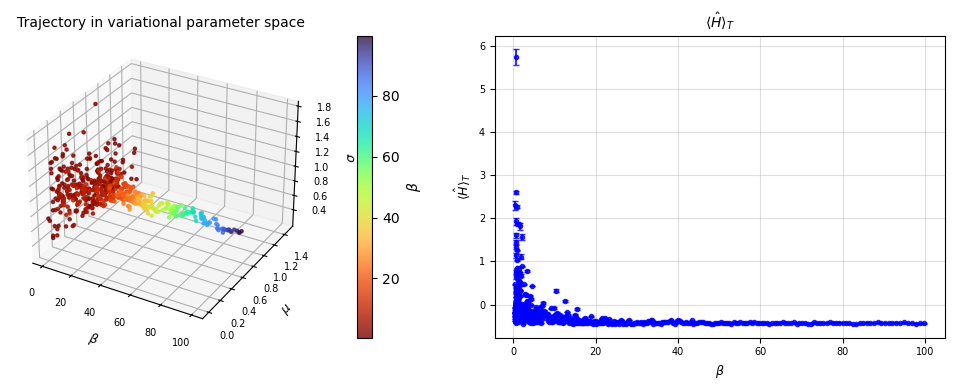

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

T, mu, sigma, obs, err = np.loadtxt("08.2/parameters.dat", unpack=True, usecols=(0,1,2,3,4), skiprows=1)
beta = 1 / T

fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc = ax1.scatter(beta, mu, sigma,
                 c=beta,
                 cmap='turbo_r',
                 marker='.',
                 s=20,
                 alpha=0.8)

ax1.set_xlabel(r"$\beta$", fontsize=9)
ax1.set_ylabel(r"$\mu$", fontsize=9)
ax1.set_zlabel(r"$\sigma$", fontsize=9)
ax1.set_title('Trajectory in variational parameter space', fontsize=10)
ax1.tick_params(axis='both', which='major', labelsize=7)
cbar = fig.colorbar(sc, ax=ax1, pad=0.1)
cbar.set_label(r'$\beta$', fontsize=10)

ax2 = fig.add_subplot(1, 2, 2)
ax2.errorbar(beta, obs, yerr=err, fmt='o', markersize=3, capsize=2, color='blue', alpha=0.8)
ax2.set_xlabel(r"$\beta$", fontsize=9)
ax2.set_ylabel(r"$\langle {\hat H} \rangle_T$", fontsize=9)
ax2.set_title(r"$\langle {\hat H} \rangle_T$", fontsize=10)
ax2.grid(True, alpha=0.4)
ax2.tick_params(axis='both', which='major', labelsize=7)

plt.tight_layout()
plt.show()


Ground state energy:  -0.46045845079911807


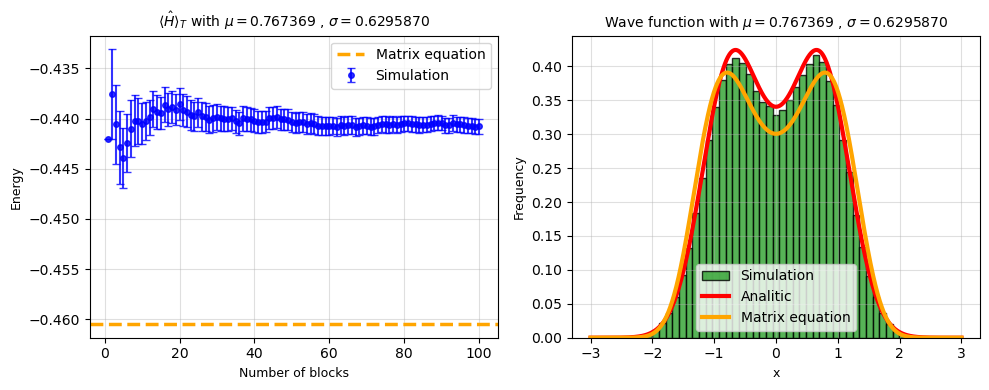

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Define the square modulus of the wave function
def squaremod_wf(x, mu, sigma):
    return (np.exp(-(x-mu)**2/(2*sigma**2))+np.exp((-(x+mu)**2/(2*sigma**2))))**2


def Vpot(x):
    return (x**2 - 2.5)*x**2

#parameters
hbar = 1
m = 1
a = 6 # settore dell'asse delle x in cui risolvo il problema. Lecito perché particella confinata in doppia buca.
N = 1000 # number of iterations
# Step sizes
x_plot = np.linspace(-a/2, a/2, N)
dx = x_plot[1] - x_plot[0] # the step size
V = Vpot(x_plot)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2
CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# np.diag(np.array,k) construct a "diagonal" matrix using the np.array
# The default is k=0. Use k>0 for diagonals above the main diagonal, 
# and k<0 for diagonals below the main diagonal

# Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)
# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)
# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)
print("Ground state energy: ", E[0])

x, y, yerr = np.loadtxt("08.1/energy_0.dat", usecols=(0, 2, 3), unpack=True)
amplitude = np.loadtxt("08.1/amplitude_0.dat", usecols=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.errorbar(x, y, yerr=yerr, fmt='o', capsize=3, markersize=4, color='blue', alpha=0.8, label='Simulation')
ax1.axhline(E[0], color='orange', linestyle='--', linewidth=2.5, label="Matrix equation")
ax1.set_xlabel("Number of blocks", fontsize=9)
ax1.set_ylabel("Energy", fontsize=9)
ax1.set_title(r"$\langle {\hat H} \rangle_T$ with $\mu = 0.767369$ , $\sigma = 0.6295870$", fontsize=10)
ax1.grid(True, alpha=0.4)
ax1.legend()

ax2.hist(amplitude, bins=50, color='tab:green', density=True,  alpha=0.8, edgecolor='black', label='Simulation')
ax2.plot(x_plot, 1. / (1.5*np.sqrt(np.pi)) * squaremod_wf(x_plot, 0.767369 , 0.6295870), linewidth = 3, color='red', label = r"Analitic")
ax2.plot(x_plot,(psi[0])**2, color = 'orange' , linewidth = 3, label = 'Matrix equation')
ax2.set_xlabel("x", fontsize=9)
ax2.set_ylabel("Frequency", fontsize=9)
ax2.set_title(r"Wave function with $\mu = 0.767369$ , $\sigma = 0.6295870$", fontsize=10)
ax2.grid(True, alpha=0.4)

plt.legend()
plt.tight_layout()
plt.show()
